# Follow the Money - How EU Research Agenda Influences the Future of Society

### HOW TO USE THIS JUPYTER NOTEBOOK: 
To run the code, either: 
- click on 'Run' in the menu bar and select 'Run All Cells'. This will run the entire code all at once and all you have to do is scroll through to find the information you need
- OR select the first cell below (it becomes highlighted in blue when selected)and press 'ENTER' + 'SHIFT' on your keyboard. This will run one chunk of code at a time and allow you to follow more closely on what the code is doing, if you want that.  

**Note: The code builds on itself so cells have to be run in order otherwise it won't update properly when you change your selection**

In [53]:
#DON'T FORGET TO RUN THIS CELL !!!!
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

## Instructions
Complete instructions on this doc: https://pad.liiib.re/rXXeznogTyuTG2tfKYqfSA?view
#### STEP 1) Choose a company from the Top 60FR list (linked in the doc)
   - The rest of the code will anaylse the top French projects that this company particpated in
   - You can pick multiple companies at once but the code will combine the results and not all steps distinguish between each company in the totals

#### STEP 2) Choose the Framework Programs to analyze:
   - 1 = Horizon Europe (2021 - 2027)
   - 2 = Horizon 2020 (2014 - 2020)
   - 3 = FP7 (2007 - 2013)
   - 4 = FP6 (2002 - 2006), note: this dataset is messy and has missing information so it may skew the results

#### OPTIONAL STEP) Choose Keywords from the EuroSciVoc List (linked in the doc). 
- This will count how many times those keywords are used to describe the projects that the chosen company is a part of
- You can leave this list empty and it will plot all of the keywords in all of the projects
  
### STEP 5) Fill Out Choices In Cell Below


In [43]:
# STEP 1) Replace AIRBUS with chosen company name in CAPITAL LETTERS (can pick multiple companies but picking a single one first is suggested)
Entreprises = ['AIRBUS']

Prog = {1: 'HORIZON', 2: 'H2020', 3: 'FP7'} #(4: 'FP6') excluding FP6 from the workshop because it is messy and has missing information

# STEP 2) Type the number followed by a comma for each of the Framework Programs you chose, for example: IncludeProgrammes = [1,2,3]
IncludeProgrammes = [1,2,3]

#OPTIONAL) type a few keywords from the official EuroSciVoc list, for example KeyWords = ['artificial intelligence','energy and fuels']
#   Leaving this blank will plot all of the keywords used to describe the project
KeyWords = ['artificial intelligence','energy and fuels']



### Filter data to find the total funding and the top funded projects

In [44]:
'''
#have different colors for cells that need input 
## use this one when accessing data file from GitHub -- ie when using BINDER link
Clean_file = 'EU-fundings-TopFRcomp.csv'

TypeSpec = {'ecContribution': float,'Source': int,'Start Date': str,'netEcContribution': str} 
EUfullTable = pd.read_csv(Clean_file,dtype = TypeSpec) 
EUfullTable['EuroSciVoc'] = EUfullTable['EuroSciVoc'].fillna('[]').apply(lambda x: eval(x))

SourceSelect = EUfullTable['source'].apply(lambda x: x in IncludeProgrammes)
EUfullTable = EUfullTable.loc[SourceSelect]

SDateSeries = EUfullTable['Start Date'].str[0:4].fillna('9999').apply(lambda x: int(x))

'''
## use this one when accessing data file from laptop

CleanFolderName = '/Users/annalewicki/Downloads/Horizon Terre/Future Earth Atelier/code/' #replace with file location on your PC
Clean_file = 'EU-fundings-TopFRcomp.csv'

TypeSpec = {'ecContribution': float,'Source': int,'Start Date': str,'netEcContribution': str} 
EUfullTable = pd.read_csv(CleanFolderName + Clean_file,dtype = TypeSpec) 
EUfullTable['EuroSciVoc'] = EUfullTable['EuroSciVoc'].fillna('[]').apply(lambda x: eval(x))

SourceSelect = EUfullTable['source'].apply(lambda x: x in IncludeProgrammes)
EUfullTable = EUfullTable.loc[SourceSelect]

SDateSeries = EUfullTable['Start Date'].str[0:4].fillna('9999').apply(lambda x: int(x))


In [45]:
### Find projects that chosen company is a part of from Clean Data (EU Fundings-TopFRcomp)

Entreprises = [x.upper() for x in Entreprises] # Put names all in capital letters 

if Entreprises != []: 
    IncludeTable = EUfullTable[['projectAcronym','Company']].groupby('projectAcronym').max()
    IncludeGroupIndex = IncludeTable['Company'].apply(lambda x: x in Entreprises)
    IncludeAc = set(IncludeTable['Company'].loc[IncludeGroupIndex].keys())
    IncludeIndex = EUfullTable['projectAcronym'].apply(lambda x: x in IncludeAc)
    EUfullTable = EUfullTable.loc[IncludeIndex]
else: 
    print(' ')
    print('COMPANY LIST EMPTY ! STATS ARE SHOWN FOR FULL LIST !')


##################### EXTRACT SERIES #####################

AcSeries = EUfullTable['projectAcronym']
SDateSeries = EUfullTable['Start Date']
LabsAndTOPSeries = EUfullTable['name']
TOPmainSeries = EUfullTable['Company']
FundSeries = EUfullTable['ecContribution']
CountrySeries = EUfullTable['country']

Nt = AcSeries.size # Total line number 


In [46]:
### Calculate the Total Funding Company Recieves and Top 3 Funded Projects


# Top 3 Projects Recieving the most EU funding
TotalNum_Prog = EUfullTable[['projectAcronym','source']].groupby('projectAcronym').max().reset_index()
TotalNum_Prog = TotalNum_Prog['source'].value_counts()
TotalNum_Prog = TotalNum_Prog.rename(index = Prog) 
TotalNum_Prog['Somme total'] = np.sum(TotalNum_Prog)
TotalNum_ProgR = TotalNum_Prog[::-1] # Reverse order

# Total Funds per program
TotalFunds_Prog = EUfullTable[['ecContribution','source']].groupby('source',group_keys=False).sum()
TotalFunds_Prog = TotalFunds_Prog['ecContribution'].rename_axis(None, axis=0) 
TotalFunds_Prog = TotalFunds_Prog.rename(index = Prog).apply(lambda x: np.round(x/1e6)) # In Millions euros
TotalFunds_Prog['Somme total'] = np.sum(TotalFunds_Prog)
TotalFunds_ProgR = TotalFunds_Prog[::-1] # Reverse order

# Total funding per project
Project_TotFunds = EUfullTable[['projectAcronym','ecContribution','EuroSciVoc']].groupby('projectAcronym').sum().reset_index()
Project_TotFunds['EuroSciVoc'] = Project_TotFunds['EuroSciVoc'].apply(lambda x: list(set(x)))
Project_TotFunds = Project_TotFunds.sort_values('ecContribution',ascending=False) 
Project_TotFunds['ecContribution'] = Project_TotFunds['ecContribution'].apply(lambda x: x/1e6)

Ntop_TotFunds = 3 # Number of highest projects to select  
Top3Project_TotFunds = Project_TotFunds.iloc[0:Ntop_TotFunds]

# Main Info
#### STEP 6) Run the code directly below

#### STEP 7) Fill out Worksheet Using Outputed Info Below
From the printed results of Main Info start filling in the Worksheet below (Company name, the total sum of money recieved over selected programs, and the top project acronym and title)

**Note: For 'Top projects' the first column is just the number of the row in the data sheet, ignore it!**

In [47]:
print(' ')
print('Total Sum (in M €):')
print(TotalFunds_Prog)

print(' ')
print('Top  projets:')
print(Top3Project_TotFunds)

print(' ')
print('Number of projets:')
print(TotalNum_Prog)

 
Total Sum (in M €):
HORIZON         548.0
H2020           647.0
FP7             536.0
Somme total    1731.0
Name: ecContribution, dtype: float64
 
Top  projets:
    projectAcronym  ecContribution  \
107   FRC GAM 2018       85.997328   
252        UNIFIED       76.715151   
189         PHARES       69.026927   

                                            EuroSciVoc  
107  [rotorcraft, aeronautical engineering, manufac...  
252                       [energy and fuels, aircraft]  
189                       [energy and fuels, aircraft]  
 
Number of projets:
source
FP7            123
H2020           85
HORIZON         51
Somme total    259
Name: count, dtype: int64


### Step 8) Run the rest of the code below (if you haven't already done so) and explore the graphs

### Plot Set up

In [48]:
Font=14
plt.rc('text', usetex=False) # FORCE NO LATEX
plt.rc('font',size=Font)
plt.rc('font',family='serif')

## Plot: NUMBER OF PROJECTS PER PROGRAMME

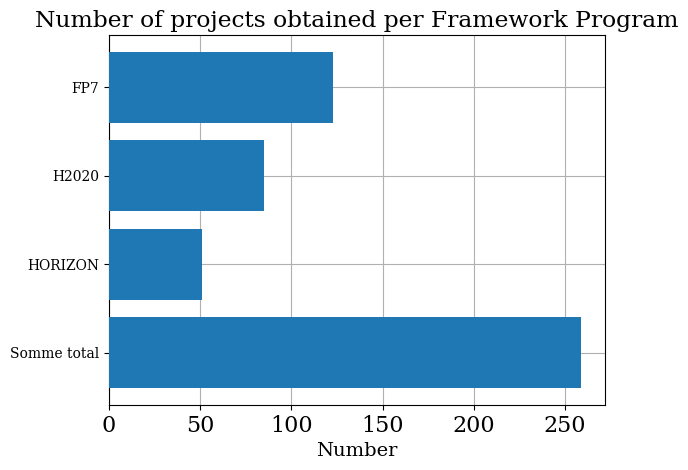

In [56]:
"""
#####################
# Comp. number of projects 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
plt.figure() 
plt.barh(TotalNum_ProgR.index,TotalNum_ProgR,color = 'tab:blue',zorder=3) 
plt.grid()
plt.title('Number of projects obtained per Framework Program')
plt.xlabel('Number')
plt.show()

## Plot: FUNDINGS PER PROGRAMME 

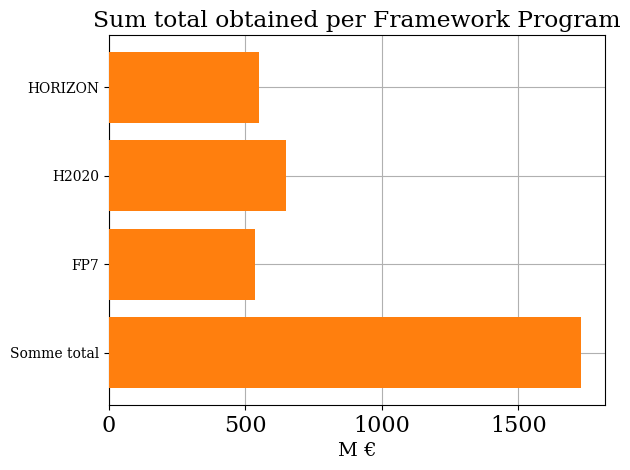

In [57]:
"""
#####################
# Comp. fundings of projects 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
plt.figure() 
plt.barh(TotalFunds_ProgR.index,TotalFunds_ProgR,color = 'tab:orange',zorder=3) 
plt.grid()
plt.title('Sum total obtained per Framework Program')
plt.xlabel('M €')
plt.show()

## Plot: FUNDINGS PER PROJECT 

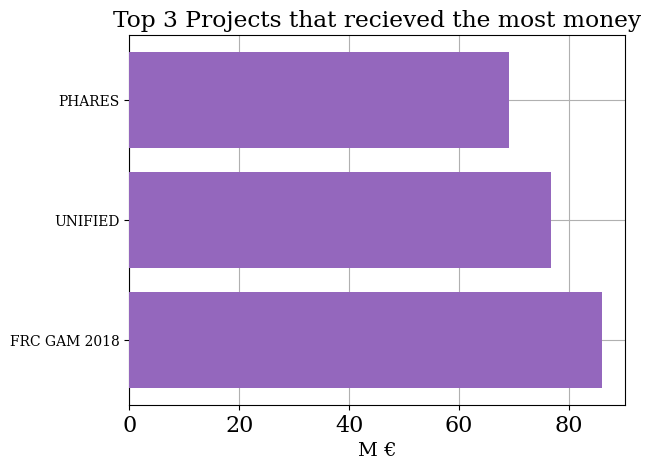

In [58]:
"""
#####################
# Top 3 projects 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
plt.figure() 
plt.barh(Top3Project_TotFunds['projectAcronym'],Top3Project_TotFunds['ecContribution'],color = 'tab:purple',zorder=3) 
plt.grid()
plt.title('Top '+str(Ntop_TotFunds)+' Projects that recieved the most money')
plt.xlabel('M €')
plt.show()


## KEYWORDS STATS 

This plot collects the keywords over all of the projects of the chosen company and counts how many times they were used. It will either plot all of the keywords or only the chosen ones you typed in the first step.

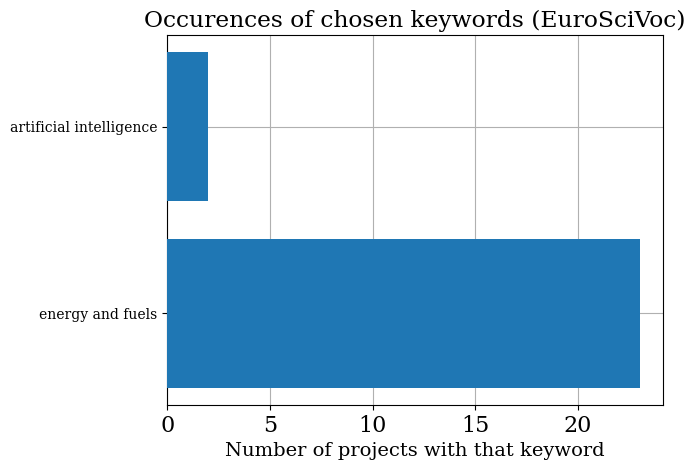

In [52]:
KeyWords_Nlist = list(EUfullTable.drop_duplicates(subset=['projectAcronym'])['EuroSciVoc']) # gives a nested list 
KeyWords_list = [item for sublist in KeyWords_Nlist for item in sublist] # Flatten the nested list 
KeyWords_set = set(KeyWords_list)

KeyWords_Count = pd.Series(KeyWords_list).value_counts() 
Nkw = 15 # Number of keywords to show 

KeyWords_RCount = KeyWords_Count.iloc[0:Nkw] 

if len(KeyWords) > 0: 
    for jk in KeyWords: 
        if jk not in KeyWords_set: 
            print(' ')
            print('Keyword "'+jk+'" not in the standard EuroSciVoc list! Has been removed.')
            KeyWords.remove(jk) 
    KeyWords_selected_index = pd.Series(KeyWords_Count.index).apply(lambda x: x in KeyWords)
    KeyWords_selected_index.index = KeyWords_Count.index 
    KeyWords_selected = KeyWords_Count.loc[KeyWords_selected_index] 

"""
#####################
#   Keywords count 
##################### 
"""
plt.rc('ytick', labelsize=10) 
plt.rc('xtick', labelsize=16) 
if len(KeyWords)>0: 
    plt.figure() 
    plt.barh(KeyWords_selected.index,KeyWords_selected,zorder=3) 
    plt.grid()
    plt.title('Occurences of chosen keywords (EuroSciVoc)')
    plt.xlabel('Number of projects with that keyword')
else: 
    plt.figure() 
    plt.barh(KeyWords_RCount.index,KeyWords_RCount,zorder=3) 
    plt.grid()
    plt.title('Most used keywords (EuroSciVoc)')
    plt.xlabel('Number of projects with that keyword')

plt.show()